# ADVERTISING

TV, Radyo ve Gazete ilanlarına göre satış rakamları var.
TV, radyo ve gazeteye ayrı ayrı ne kadar yatırım yaparsam satış rakamlarım ne kadar artar sorusuna cevap arıyoruz. Hangi reklam yönteminin daha başarılı olduğunu bulacağız. Tahmin verileri ile test verileri grafikler ile görselleştirilecektir.

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df=pd.read_csv('advertising.csv')

In [23]:
# EDA yaparak verileri tanıyacağız.

In [24]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [25]:
df.sample(5)

,TV,Radio,Newspaper,Sales
3,151.5,41.3,58.5,18.5
97,184.9,21.0,22.0,15.5
28,248.8,27.1,22.9,18.9
70,199.1,30.6,38.7,18.3
121,18.8,21.7,50.4,7.0


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [27]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [28]:
# 200 satırlık boş olmayan ve değerleri float olan bir veri setimiz mevcut.

In [29]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [30]:
# bu tablo incelendiğinde en fazla reklam harcamasının TV alanına, sonra gazeteye, sonra da radio ya yapıldığı söylenebilir.

In [31]:
df.corr(numeric_only=True)

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


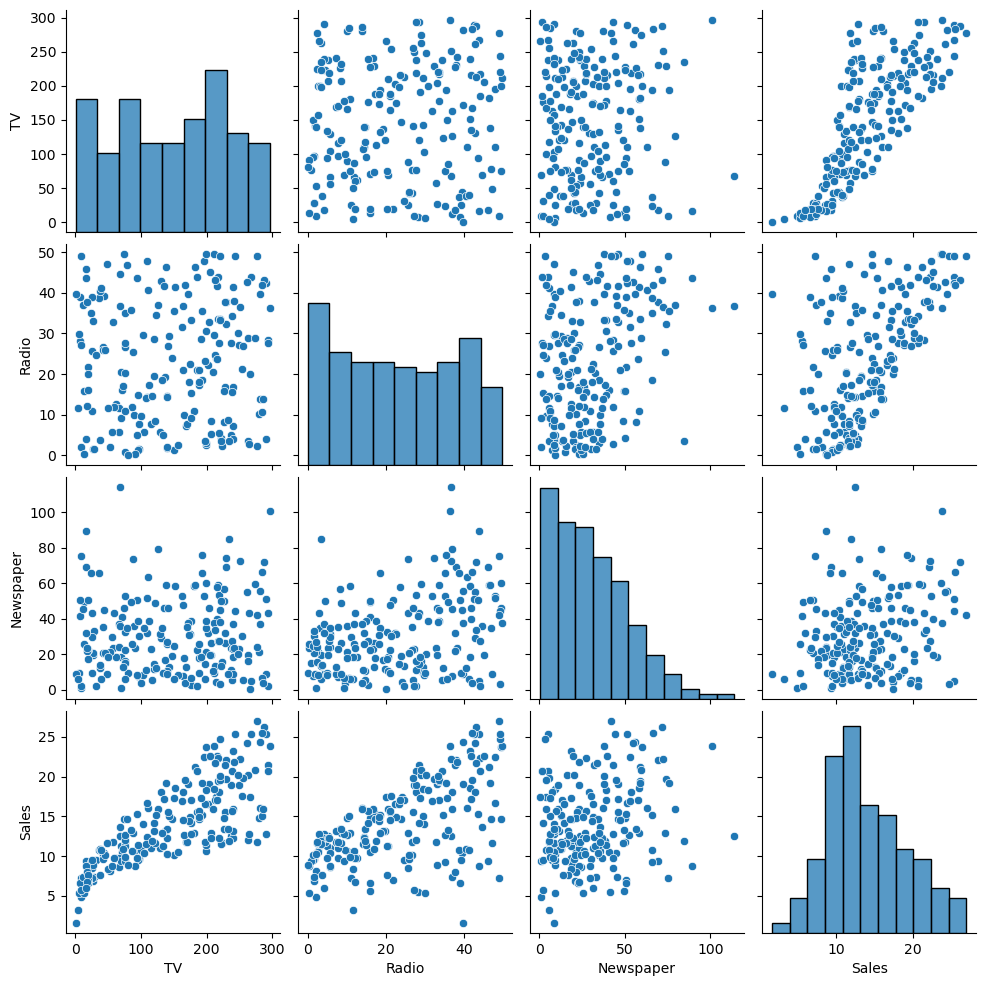

In [32]:
sns.pairplot(df)

In [38]:
df_sort = df.sort_values(by='Sales').reset_index(drop=True)
df_sort

,TV,Radio,Newspaper,Sales
0,0.7,39.6,8.7,1.6
1,4.1,11.6,5.7,3.2
2,8.6,2.1,1.0,4.8
3,13.1,0.4,25.6,5.3
4,5.4,29.9,9.4,5.3
...,...,...,...,...
195,289.7,42.3,51.2,25.4
196,243.2,49.0,44.3,25.4
197,283.6,42.0,66.2,25.5
198,287.6,43.0,71.8,26.2


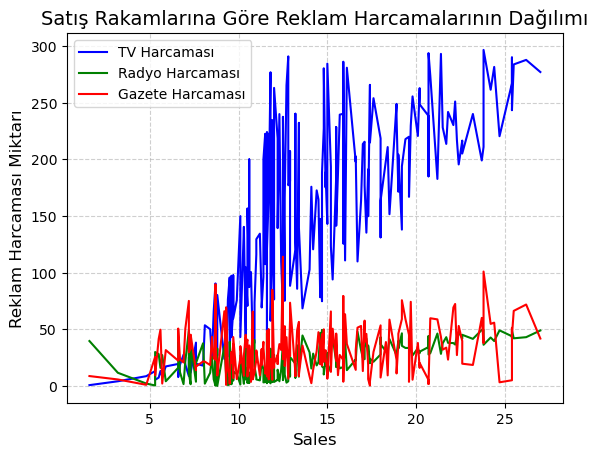

In [49]:
plt.plot(df_sorted['Sales'], df_sorted['TV'], label='TV Harcaması', color='blue', alpha=1)
plt.plot(df_sorted['Sales'], df_sorted['Radio'], label='Radyo Harcaması', color='green', alpha=1)
plt.plot(df_sorted['Sales'], df_sorted['Newspaper'], label='Gazete Harcaması', color='red', alpha=1)
plt.title('Satış Rakamlarına Göre Reklam Harcamalarının Dağılımı', fontsize=14)
plt.xlabel('Sales', fontsize=12)
plt.ylabel('Reklam Harcaması Miktarı', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### korelasyon incelendiğinde TV reklamlarının satışların artmasına etkisinin daha fazla korelasyon analizine baktığımızda TV (0.78**2=%60), Radio (0.57**2=%32), Newspaper (0.22**2=%4) bu verilerden yola çıkarak satışlardaki artışa tv reklamlarının etkisinin %60 civarında olduğunu, aynı şekilde diğerlerinin sırasıyla %30 ve %4 civarında olduğunu söyleyebiliriz.

In [85]:
#şimdi buradaki temel nokta hangi miktarlarda yapılan yatırımların ne kadar satış rakamına etki edeceğini tahmin edebilmek. 
#Bu amaçla sales değişkenini bağımlı diğer değişkenleri bağımsız değişken olarak ela alıp fit-predict yaptırmak gerekecektir.
# Bu çerçevede Linearregression algoritması kullanılabilir.

In [86]:
# öncesinde uç değerler var mı bakalım

<Axes: >

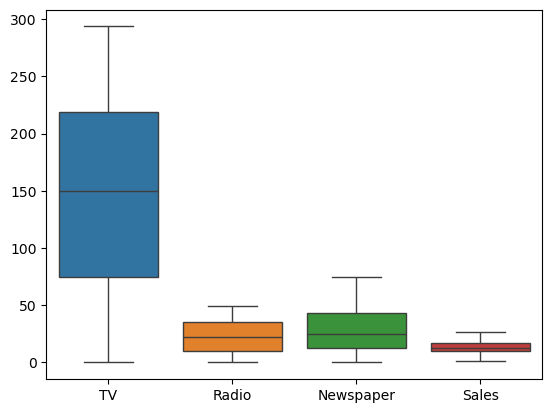

In [87]:
sns.boxplot([df['TV'], df['Radio'], df['Newspaper'], df['Sales']])

In [88]:
#Newspaper da uç değerlerim var bunları elemek için %97 kuralınımı kullansam yoksa ortalamadan 3 standart sapma alıp bunu geçen 
#verileri mi elesem newspaper verilerimin normal dağılıp dağılmadığını görsellemem lazım.

<Axes: xlabel='Newspaper', ylabel='Density'>

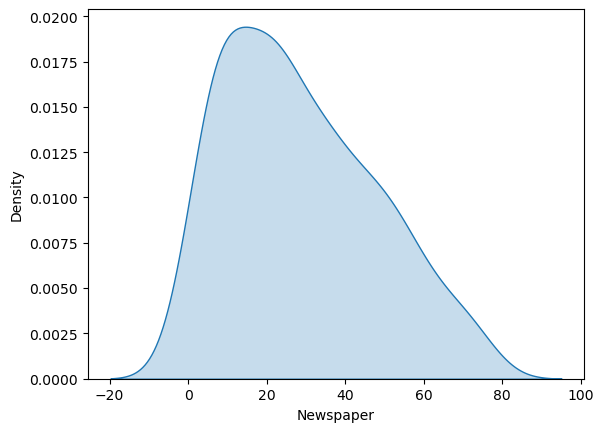

In [89]:
sns.kdeplot(x=df['Newspaper'], fill=True) # grafiğe göre normal dağılım sözkonusu değil bu durumda %97 lik kısma gelen verileri silelim.

In [90]:
outliers=df.quantile(q=.97, numeric_only=True)
df=df[(df['Newspaper']<outliers['Newspaper'])]

In [91]:
df.shape

(188, 5)

In [92]:
# bu aşamada tahmin işlemine geçmeden Feature Engineering yaparak TV ve Radio etkisinden yola çıkarak 4. bir sütun oluşturalım 
# çünkü tv ve radionun sales'e etkisi çok daha fazla 

In [93]:
df['TVveRadio']=df['TV']*df['Radio'];

In [94]:
df.head()

,TV,Radio,Newspaper,Sales,TVveRadio
0,230.1,37.8,69.2,22.1,8697.78
1,44.5,39.3,45.1,10.4,1748.85
3,151.5,41.3,58.5,18.5,6256.95
4,180.8,10.8,58.4,12.9,1952.64
6,57.5,32.8,23.5,11.8,1886.00


In [95]:
df.shape

(188, 5)

In [96]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [97]:
x=df[['TV', 'Radio', 'Newspaper', 'TVveRadio']]
y=df['Sales']
x_train, x_test, y_train, y_test=train_test_split(x,y, random_state=42, test_size=22)

In [98]:
lr=LinearRegression()

In [111]:
model=lr.fit(x_train,y_train)
tahmin=model.predict(x_test)

In [112]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [113]:
r2_score(y_test, tahmin)

0.9764202341110699

In [114]:
mean_squared_error(y_test, tahmin)

0.615001705129175

In [115]:
mean_absolute_error(y_test, tahmin)

0.636385267741677

In [116]:
residuals=y_test-tahmin

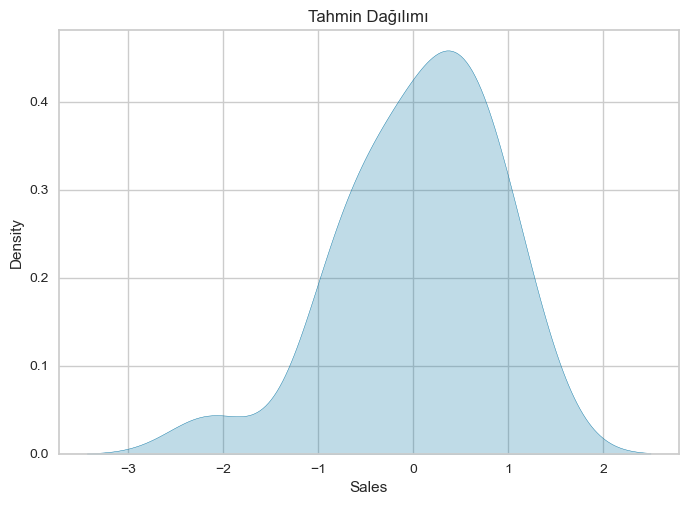

In [117]:
sns.kdeplot(residuals, fill=True)
plt.title("Tahmin Dağılımı")
plt.show()

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


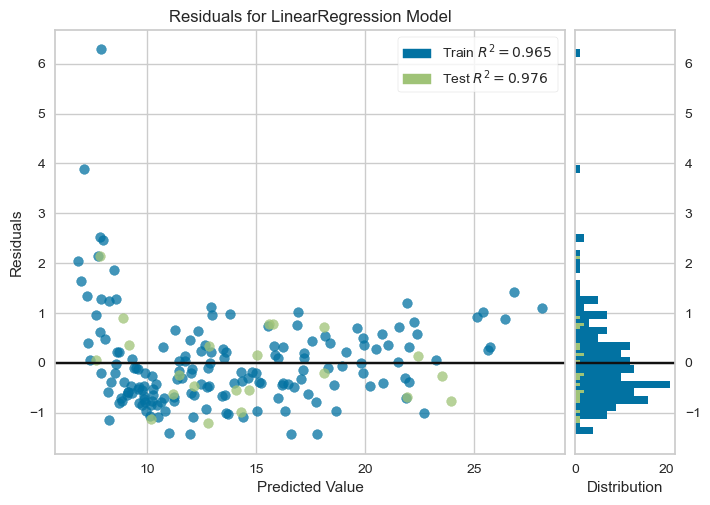

In [118]:
from yellowbrick.regressor import ResidualsPlot
vis=ResidualsPlot(lr)
vis.fit(x_train, y_train)
vis.score(x_test, y_test)
vis.show();

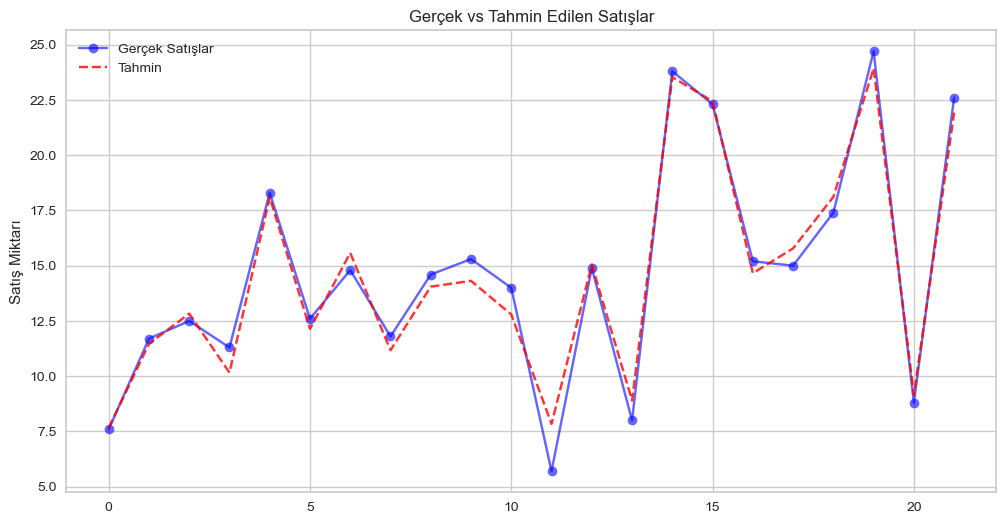

In [121]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Gerçek Satışlar', color='blue', marker='o', alpha=0.6)
plt.plot(model.predict(x_test), label='Tahmin', color='red', linestyle='--', marker='x', alpha=0.8)

plt.title('Gerçek vs Tahmin Edilen Satışlar')
plt.ylabel('Satış Miktarı')
plt.legend()
plt.grid(True)
plt.show()

### tahmin oranı oldukça iyigözükmete tahmin oranı olarak R^2 'yi '.97, RMSE'u ise .61 olarak bulduk.

In [122]:
print(model.coef_) # burada coef_ Coefficient" (Katsayı) kelimesinin kısaltmasıdır. 
# coef_ ile her bağımsız değişkenin bağımlı değişken üzerindeki etkisi belirlenir.

[0.01990884 0.03117496 0.00373196 0.00105852]


### verilere bakıldığında satışlarda ençok verimin radioya yapılan yatırımdan sağlandığı ikinci TV'den ardından newspaperdan sağlandığı söylenebilir.

In [124]:
print(model.intercept_) #modeldeki sabit sayı. Bu arada oluşturduğumuz modelin formule edilmiş hali şu şekildedir.
# model= Sabit Sayı + (A.TV)+ (B.Radio)+ (C.Newspaper)+ (D.TVveRadio)  buradaki abcd değerleri coefficient lardır.

6.577684963510293
